In [23]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from datetime import datetime
from datetime import timedelta

In [3]:
def parser(s):
    return datetime.strptime(s, '%Y-%m-%d')

In [4]:
def perform_adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])

In [5]:
series = pd.read_csv('catfish.csv', parse_dates=[0], index_col=0)

In [6]:
series = series.asfreq(pd.infer_freq(series.index))
series = series.loc[datetime(2004,1,1):]

In [7]:
series_1 = series.diff().dropna()

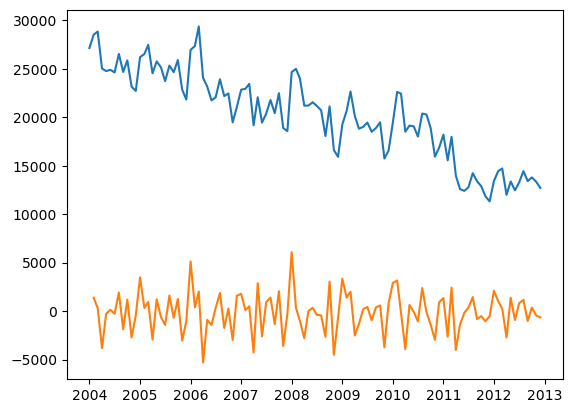

In [8]:
plt.plot(series)
plt.plot(series_1)

In [9]:
perform_adf_test(series_1)

ADF Statistic: -2.166819
p-value: 0.218508


In [10]:
series_2 = series_1.diff().dropna()

In [11]:
perform_adf_test(series_2)

ADF Statistic: -7.162321
p-value: 0.000000


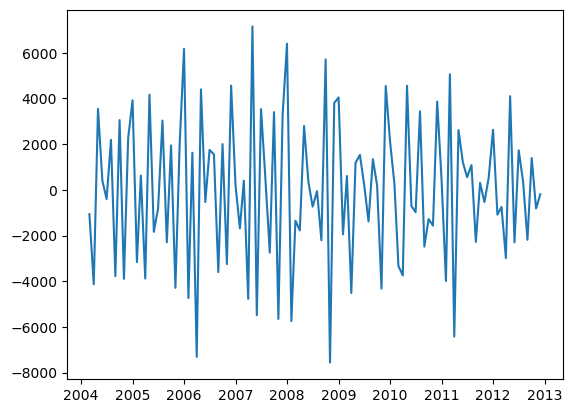

In [12]:
plt.plot(series_2)

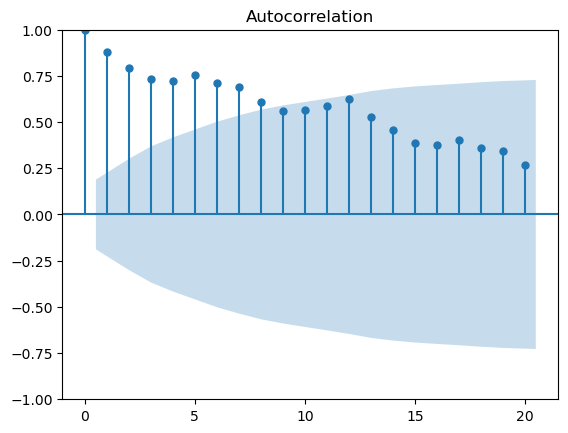

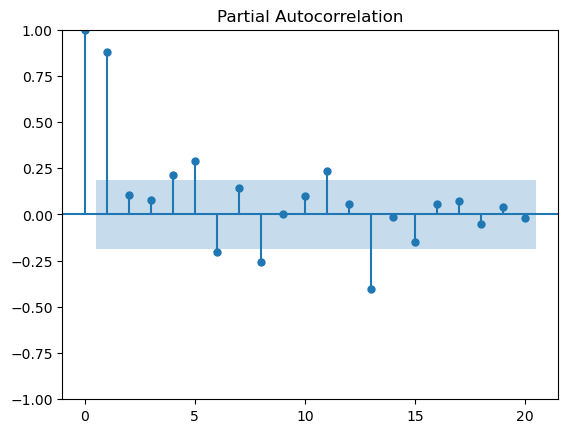

In [13]:
plot_acf(series, lags=20)
plot_pacf(series, lags=20)
plt.show()

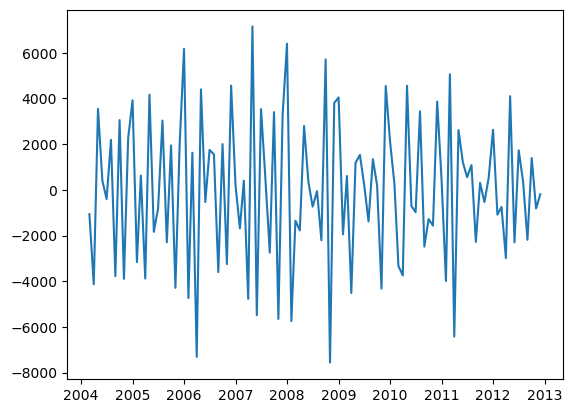

In [12]:
plt.plot(series_2)

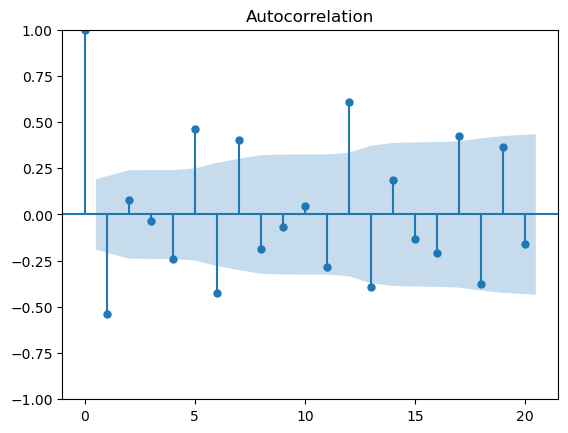

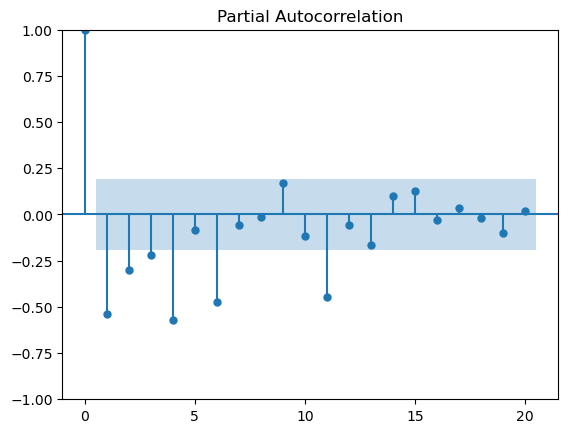

In [23]:
plot_acf(series_2, lags=20)
plot_pacf(series_2, lags=20)
plt.show()

In [14]:
ar_orders = [1, 2, 3]
ma_orders = [5, 6, 7]
fitted_model_dict = {}

for ar_order in ar_orders:
    for ma_order in ma_orders:
        # Create ARMA(p,q) model
        arma_model = ARIMA(series_2, order=(ar_order, 0, ma_order))
        arma_model_fit = arma_model.fit()
        fitted_model_dict[(ar_order, ma_order)] = arma_model_fit

C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

In [15]:
from statsmodels.tsa.arima.model import ARIMA
from itertools import product

p_values = range(1, 3)
q_values = range(1, 3)

fitted_model_dict = {}

for p, q in product(p_values, q_values):
    # Create ARMA(p,q) model
    arma_model = ARIMA(series_2, order=(p, 0, q))
    arma_model_fit = arma_model.fit()
    
    # Store AIC and BIC scores
    aic_score = arma_model_fit.aic
    bic_score = arma_model_fit.bic
    
    fitted_model_dict[(p, q)] = {'AIC': aic_score, 'BIC': bic_score}

# Print AIC and BIC scores for each combination


C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [18]:
series_2.tail(5)

,Total
Date,
2012-08-01,353.0
2012-09-01,-2186.0
2012-10-01,1393.0
2012-11-01,-816.0
2012-12-01,-193.0


In [16]:
for (p, q), scores in fitted_model_dict.items():
    print(f'ARMA({p},{q}) - AIC: {scores["AIC"]}, BIC: {scores["BIC"]}')


ARMA(1,1) - AIC: 1925.101919495318, BIC: 1935.7556758717662
ARMA(1,2) - AIC: 1929.6905783955704, BIC: 1943.0077738661307
ARMA(2,1) - AIC: 1924.155957373285, BIC: 1937.4731528438454
ARMA(2,2) - AIC: 1921.777593537451, BIC: 1937.7582281021232


In [24]:
train_end = datetime(2011,12,1)
test_end = datetime(2012,12,1)

train_data = series_2[:train_end]
test_data = series_2[train_end + timedelta(days=1):test_end]

In [25]:
model = ARIMA(train_data, order=(2,0,2))

In [26]:
model_fit = model.fit()

C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Indra\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [27]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Total   No. Observations:                   94
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -849.847
Date:                Mon, 23 Dec 2024   AIC                           1711.693
Time:                        16:22:16   BIC                           1726.953
Sample:                    03-01-2004   HQIC                          1717.857
                         - 12-01-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1447      6.958     -0.308      0.758     -15.782      11.492
ar.L1         -1.0570      0.132     -8.013      0.000      -1.316      -0.798
ar.L2         -0.3114      0.105     -2.972      0.0

In [28]:
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]

In [29]:
pred_end_date

Timestamp('2012-12-01 00:00:00')

In [30]:
predictions = model_fit.predict(start=pred_start_date, end=pred_end_date)
residuals = test_data - predictions

In [31]:
predictions

2012-01-01    196.936569
2012-02-01    181.192042
2012-03-01   -257.929756
2012-04-01    211.140336
2012-05-01   -147.946022
2012-06-01     85.558045
2012-07-01    -49.448725
2012-08-01     20.547768
2012-09-01    -11.401468
2012-10-01      0.573911
2012-11-01     -2.135867
2012-12-01     -3.000530
Freq: MS, Name: predicted_mean, dtype: float64

Text(0, 0.5, 'Sales')

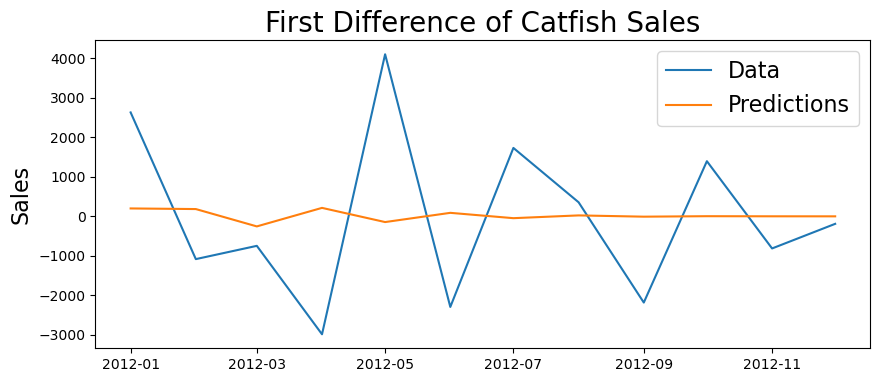

In [32]:
plt.figure(figsize=(10,4))

plt.plot(test_data)
plt.plot(predictions)

plt.legend(('Data', 'Predictions'), fontsize=16)

plt.title('First Difference of Catfish Sales', fontsize=20)
plt.ylabel('Sales', fontsize=16)


In [34]:
# Getting actual value from the differenced value

def invert_diff(last_actual, differences):
    inverted_values = []
    last_observation = last_actual
    for diff in differences:
        inverted_value = last_observation + diff
        inverted_values.append(inverted_value)
        last_observation = inverted_value
    return inverted_values

In [35]:
actual_values = pd.Series([100, 105, 110, 115, 120])

# Sample differenced data (assuming first order differencing)
differenced_data = pd.Series([5, 5, 5, 5])

# Sample model forecast (assuming one-step-ahead forecast)


In [36]:
actual_values = pd.Series([100, 105, 110, 115, 120])
actual_values.iloc[-1]

120

In [37]:
invert_diff(actual_values.iloc[-1],differenced_data)

[125, 130, 135, 140]